# SnapKV Token Dropping Example with LMCache SDK (decode optimization ver.)
---

Long prompts create large KV caches that eat up GPU memory and limit how many 
requests fit in a batch, and a smaller batch means lower decode throughput. 
Token dropping shrinks each request's KV cache (in this example by half), so more
requests fits in a batch. This notebook shows improvement in decode 
throughput by 1.5-1.7x by using LMCache's SDK API that enables ML engineers get
a requests' KV, do optimizations such as token dropping, and put it back to use
during LLM serving.

Additionally, this example proves that the accuracy of generation is unaffected,
even improved, by token dropping.

Requirements:
* A small 10-lines modification is needed on vLLM's side to expose intermediate
  tensors to LMCache. Please do the setup steps outlined in 
  [README.md](./README.md)
* This experiment requires a GPU. To demonstrate how token dropping increases 
  the decoding batch size, adjust the GPU memory utilization together with the 
  number of requests. This example uses one RTX 6000 PRO.
* This example uses shared memory for data transfer between LMCache server and
  the SDK. If shared memory is unavailable, the SDK automatically falls back to pickle.

How this notebook different from the snapkv_token_dropping.ipynb:
- snapkv_token_dropping.ipynb only does token dropping to the prompt. Decoded
  tokens are not optimized. This is because, the query tensors are not obtained
  for decoding phase, previously.
- Now we made improvement to the SDK. The SDK now obtains query tensor for decode
  phase by gathering query tensors across steps. Each request gets a block table
  over the paged Q ring, keyed by request ID and mirroring vLLM's KV block table,
  so a chunk built up one token at a time is stored once its last token arrives.
- This is to accommodate the existing lookup, which read-locks only the leading run
  of cached chunks and stops at the first miss. Rooted at token 0, that first miss
  lands on the compacted prefix: those tokens come from the KV cache, so they never
  produced query rows and nothing was ever stored for them. The decoded tail is
  in L1, but the lookup stops before reaching it, and chunks it never locked cannot
  be read. Rooted at the segment instead, the pass's output is a gap-free prefix, so
  the lookup locks all of it.

## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`
To enable query tensor transfer, we pass `--enable transfer_query`.

```sh
lmcache server \
    --l1-size-gb 300 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8081 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy \
    --enable transfer_query \
    --eviction-trigger-watermark 0.95
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.q.ring_depth":10}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids \
    --max-num-batched-tokens 8000
```

To enable query tensor transfer, pass 
`"lmcache.mp.transfer_intermediate_tensors":true` as an additional argument
to `--kv-transfer-config`. To adjust the QRingBuffer capacity, which holds
the query tensor temporarily before storing in L1, pass `"lmcache.mp.q.ring_depth"`
which defaults to 2 (2 means the QRingBuffer can hold the query tensors of 2
forward passes).

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

In [ ]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once
from utils import (
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)

/home/rani/LMCache/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-08-13 00:43:57,243] LMCache INFO: torch_dev=<module 'torch.cuda' from '/home/rani/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (_device_detect.py:143:lmcache.v1.platform._device_detect)
[2026-08-13 00:43:57,316] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.3rc3.dev5 (g6bcb00eb)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [ ]:
model_name = "Qwen/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8081"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True
decode_turns = 2  # prefill - decode 2x
# first decode to show improvement from token dropping for prefilled prompt
# second decode to show additional improvement from dropping tokens generated
# during the first decode

## Configuring the model and LMCache endpoint

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    span=lmc_sdk.ALL_SPAN,  # the whole decoded segment
    timeout=timeout,
)

[2026-08-13 00:43:58,444] LMCache INFO: Initialized LMCacheSDKContext with instance_id=1856712245724471242, model_name=Qwen/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:130:lmcache.sdk.context)
[2026-08-13 00:43:58,447] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:879:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-08-13 00:43:58,539] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-08-13 00:43:58,545] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)
[2026-08-13 00:43:58,546] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=322122547200) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-08-13 00:43

## Constructing Prompt

In [4]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    if i >= 10:
        break
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Loaded 10 prompts from the dataset.
Total prompts length: 114272 tokens.
Mean prompt length: 11427.20 tokens.
Max prompt length: 13010 tokens.
Min prompt length: 10159 tokens.


## Baseline (without token dropping)

In [10]:
batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    request = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)
results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

logger.info("\n\n")

texts_per_round, lengths_per_round = [], []
for r in range(decode_turns):
    results = batch.decode(
        sampling_params={
            "max_tokens": max_tokens,
            "temperature": temperature,
            "ignore_eos": True,
        }
    )
    results.emit()
    texts_per_round.append([s.output_text for s in batch.request_streams.values()])

before_drop_data = results.to_dict()
before_texts = texts_per_round[-1]

[2026-08-13 00:53:22,612] LMCache INFO: 

 (1753196224.py:14:__main__)


======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         6.56
Total Input Tokens:                                                       114272
Input Throughput (tokens/s):                                            17432.49
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       159.05
Total Output Tokens:        

## Clear LMCache

In [9]:
!curl -X POST {lmcache_url}/cache/clear

{"status":"ok","cleared":{"tier":"l1"}}

## With Token Dropping

In [6]:
CUDA_VISIBLE_DEVICES = "0"

snapkv_window_size = 64
snapkv_drop_ratio = 0.5
snapkv_kernel_size = 5
snapkv_pooling = "avgpool"


def _normalize_q_tensor(q_tensor: torch.Tensor) -> torch.Tensor:
    """Return q as [num_layers, T, num_q_heads * head_size]."""
    if q_tensor.ndim == 4:
        if q_tensor.shape[0] != 1:
            raise ValueError(f"expected q_tensor first dim 1, got {q_tensor.shape}")
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"expected q_tensor 3D or 4D, got {q_tensor.shape}")


def _snapkv_layer_scores(
    k_flat: torch.Tensor,
    q_flat: torch.Tensor,
    *,
    seq_len: int,
    window_size: int,
    kernel_size: int,
    pooling: str,
    num_kv_heads: int,
    num_q_heads: int,
    head_size: int,
    device: torch.device,
) -> torch.Tensor:
    """Return one importance score per non-window past token."""
    if num_q_heads % num_kv_heads != 0:
        raise ValueError(
            f"num_q_heads ({num_q_heads}) must be divisible by "
            f"num_kv_heads ({num_kv_heads})"
        )

    groups = num_q_heads // num_kv_heads
    past_len = seq_len - window_size

    k = k_flat[:seq_len].to(device=device, dtype=torch.float32)
    q = q_flat.to(device=device, dtype=torch.float32)

    k = k.reshape(seq_len, num_kv_heads, head_size).permute(1, 0, 2)
    q = q.reshape(q.shape[0], num_kv_heads, groups, head_size)

    q_recent = q[-window_size:].permute(1, 2, 0, 3)

    attn = torch.einsum("kgwd,ktd->kgwt", q_recent, k) / math.sqrt(head_size)

    causal = torch.triu(
        torch.full(
            (window_size, window_size),
            torch.finfo(attn.dtype).min,
            dtype=attn.dtype,
            device=device,
        ),
        diagonal=1,
    )
    attn[..., -window_size:] += causal

    attn = F.softmax(attn, dim=-1, dtype=torch.float32)
    past_scores = attn[..., :past_len].sum(dim=-2)

    channels = past_scores.reshape(1, -1, past_len)
    if pooling == "avgpool":
        channels = F.avg_pool1d(
            channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1
        )
    elif pooling == "maxpool":
        channels = F.max_pool1d(
            channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1
        )
    else:
        raise ValueError(f"Pooling method not supported: {pooling}")

    return channels[..., :past_len].reshape(-1, past_len).mean(dim=0)


def drop_tokens_fn(
    tensors: dict[lmc_sdk.context.LMCacheSDKCacheKind, torch.Tensor],
    token_source: list[int],
) -> tuple[torch.Tensor, list[int]]:
    """SnapKV token dropping: keep top-scored past tokens plus the last window."""
    q_tensor = tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY]
    kv_tensor = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]

    q_by_layer = _normalize_q_tensor(q_tensor)

    q_len = q_by_layer.shape[1]
    kv_len = kv_tensor.shape[2]
    logger.info(
        "modify: KV covers %d tokens, query covers %d — tokens [%d, %d)",
        kv_len,
        q_len,
        kv_len - q_len,
        kv_len,
    )

    seq_len = min(kv_tensor.shape[2], len(token_source))
    if q_by_layer.shape[1] < snapkv_window_size:
        raise ValueError(
            f"Q window has {q_by_layer.shape[1]} rows, need >= {snapkv_window_size}"
        )

    num_q_heads = config.num_attention_heads
    num_kv_heads = getattr(config, "num_key_value_heads", num_q_heads)
    head_dim = getattr(config, "head_dim", config.hidden_size // num_q_heads)

    if kv_tensor.shape[-1] != num_kv_heads * head_dim:
        raise ValueError(
            f"KV hidden dim {kv_tensor.shape[-1]} != {num_kv_heads * head_dim}"
        )
    if q_by_layer.shape[-1] != num_q_heads * head_dim:
        raise ValueError(
            f"Q hidden dim {q_by_layer.shape[-1]} != {num_q_heads * head_dim}"
        )

    past_len = seq_len - snapkv_window_size
    if past_len <= 0:
        raise ValueError(
            f"seq_len ({seq_len}) must exceed window ({snapkv_window_size})"
        )

    # do token dropping only on the newly decoded tokens
    past_start = seq_len - q_by_layer.shape[1]
    if not 0 <= past_start <= past_len:
        raise ValueError(
            f"query window ({q_by_layer.shape[1]}) inconsistent with "
            f"seq_len ({seq_len})"
        )
    new_len = seq_len - past_start
    total_keep_new = int(round(new_len * (1 - snapkv_drop_ratio)))
    keep_past = max(0, min(total_keep_new - snapkv_window_size, past_len - past_start))

    # # Total tokens to retain, including recent window here
    # total_keep = int(round(seq_len * (1 - snapkv_drop_ratio)))
    # keep_past = max(0, min(total_keep - snapkv_window_size, past_len))

    scores = torch.zeros(past_len, dtype=torch.float32, device=work_device)
    for layer in range(kv_tensor.shape[1]):
        scores += _snapkv_layer_scores(
            kv_tensor[0, layer],
            q_by_layer[layer],
            seq_len=seq_len,
            window_size=snapkv_window_size,
            kernel_size=snapkv_kernel_size,
            pooling=snapkv_pooling,
            num_kv_heads=num_kv_heads,
            num_q_heads=num_q_heads,
            head_size=head_dim,
            device=work_device,
        )
    scores /= kv_tensor.shape[1]

    # past_keep = torch.topk(scores, k=keep_past, largest=True).indices.sort().values
    # last_window = torch.arange(past_len, seq_len, device=work_device)
    # keep_idx = torch.cat([past_keep, last_window]).to(dtype=torch.long)
    # # keep_idx = torch.arange(seq_len, device=work_device)
    cand_scores = scores[past_start:]
    past_keep = (
        torch.topk(cand_scores, k=keep_past, largest=True).indices.sort().values
        + past_start
    )
    protected = torch.arange(past_start, device=work_device)
    last_window = torch.arange(past_len, seq_len, device=work_device)
    keep_idx = torch.cat([protected, past_keep, last_window]).to(dtype=torch.long)

    keep_idx_cpu = keep_idx.cpu()
    kept_ids = [token_source[i] for i in keep_idx_cpu.tolist()]

    e_kv = rerotate_k_cache(
        kv_tensor[:, :, keep_idx_cpu, :].clone().to(work_device),
        old_positions=keep_idx,
        new_positions=torch.arange(keep_idx.numel(), device=work_device),
        model_config=config,
    )

    logger.info(f"compacted {e_kv.shape[2]}/{kv_tensor.shape[2]} tokens.")

    return e_kv.cpu(), kept_ids

In [7]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    request = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)
    stream_ids.append(request.request_stream_id)

results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

texts_per_round, lengths_per_round = [], []
for r in range(decode_turns):
    batch.modify(drop_tokens_fn).emit()
    lengths_per_round.append([len(s.tokens) for s in batch.request_streams.values()])
    logger.info("round %d kept: %s", r, lengths_per_round[-1])

    results = batch.decode(
        sampling_params={
            "max_tokens": max_tokens,
            "temperature": temperature,
            "ignore_eos": True,
        }
    )
    results.emit()
    texts_per_round.append([s.output_text for s in batch.request_streams.values()])

after_drop_data = results.to_dict()
after_texts = texts_per_round[-1]

======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         6.75
Total Input Tokens:                                                       114272
Input Throughput (tokens/s):                                            16920.53


[2026-08-13 00:44:52,764] LMCache INFO: modify: KV covers 10240 tokens, query covers 10240 — tokens [0, 10240) (1838972721.py:94:__main__)
[2026-08-13 00:44:53,035] LMCache INFO: modify: KV covers 9984 tokens, query covers 9984 — tokens [0, 9984) (1838972721.py:94:__main__)
[2026-08-13 00:44:53,212] LMCache INFO: modify: KV covers 10752 tokens, query covers 10752 — tokens [0, 10752) (1838972721.py:94:__main__)
[2026-08-13 00:44:53,269] LMCache INFO: modify: KV covers 12288 tokens, query covers 12288 — tokens [0, 12288) (1838972721.py:94:__main__)
[2026-08-13 00:44:53,312] LMCache INFO: modify: KV covers 10752 tokens, query covers 10752 — tokens [0, 10752) (1838972721.py:94:__main__)
[2026-08-13 00:44:53,354] LMCache INFO: modify: KV covers 11264 tokens, query covers 11264 — tokens [0, 11264) (1838972721.py:94:__main__)
[2026-08-13 00:44:53,416] LMCache INFO: modify: KV covers 12544 tokens, query covers 12544 — tokens [0, 12544) (1838972721.py:94:__main__)
[2026-08-13 00:44:53,454] LMCa

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        19.98
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       130.13
Total Output Tokens:                                                       51200
Decode Throughput (tokens/s):                                             393.44


[2026-08-13 00:47:22,586] LMCache INFO: modify: KV covers 10240 tokens, query covers 5120 — tokens [5120, 10240) (1838972721.py:94:__main__)
[2026-08-13 00:47:22,853] LMCache INFO: modify: KV covers 10240 tokens, query covers 5376 — tokens [4864, 10240) (1838972721.py:94:__main__)
[2026-08-13 00:47:22,974] LMCache INFO: modify: KV covers 10752 tokens, query covers 5120 — tokens [5632, 10752) (1838972721.py:94:__main__)
[2026-08-13 00:47:22,998] LMCache INFO: modify: KV covers 10752 tokens, query covers 5120 — tokens [5632, 10752) (1838972721.py:94:__main__)
[2026-08-13 00:47:23,003] LMCache INFO: modify: KV covers 11264 tokens, query covers 5120 — tokens [6144, 11264) (1838972721.py:94:__main__)
[2026-08-13 00:47:23,020] LMCache INFO: modify: KV covers 11520 tokens, query covers 5376 — tokens [6144, 11520) (1838972721.py:94:__main__)
[2026-08-13 00:47:23,038] LMCache INFO: modify: KV covers 10496 tokens, query covers 5120 — tokens [5376, 10496) (1838972721.py:94:__main__)
[2026-08-13 0

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        21.85
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       145.35
Total Output Tokens:                                                       51200
Decode Throughput (tokens/s):                                             352.25


### Accuracy

In [11]:
before_correct, total, before_map = score_answers(answers, before_texts)
after_correct, total, after_map = score_answers(answers, after_texts)
logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"Token dropping: {after_correct}/{total} correct "
    f"({100 * after_correct / total:.1f}%)"
)

[2026-08-13 00:59:26,554] LMCache INFO: Baseline (no drop): 2/10 correct (20.0%) (3655945089.py:3:__main__)
[2026-08-13 00:59:26,554] LMCache INFO: Token dropping: 3/10 correct (30.0%) (3655945089.py:7:__main__)


## Result Plot

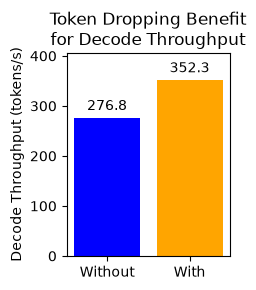

In [12]:
labels = ["Without", "With"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    after_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Close both contexts

In [13]:
# Only close the context when done.
ctx.close()
qctx.close()